Oppgave 3a)

In [6]:
import numpy as np
from matplotlib import pyplot as plt
#programmet er strukturert slik at konstanter defineres først og brukes deretter globalt av funksjonene


#konstanter                      #konstant for potensialfunksjonen
alfa = 0.8
Tp = 500
h = 1                       
Nx = 100
dt = 1               
beta_k = 1000                                                
timeSteps = 20*Tp


#
def V1(x):                #uten k fordi den inngår i p_pos
    periode = x % Nx

    if periode <= alfa*Nx:
        return periode/(alfa*Nx)
    else:
        return (periode-Nx)/((1-alfa)*Nx)

def V2(x):                          #også uten k for samme grunn
    return 0



#Henholdsvise sannsynlighetsfunksjoner p+, p0 og p-
def p_pos(x, V):
    L = 2*Nx

    #får litt numerisk overflow hvis jeg ikke clipper
    arg1 = np.clip(-beta_k*(V((x-1)%L)-V((x+1)%L)), -700, 700)
    arg2 = np.clip(-beta_k*(V(x%L)-V((x+1)%L)), -700, 700)

    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)

    return 1/nevner


def p_0(x, V):
    L = 2*Nx

    arg1 = np.clip(-beta_k*(V((x-1)%L)-V(x%L)), -700, 700)
    arg2 = np.clip(-beta_k*(V((x+1)%L)-V(x%L)), -700, 700)

    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)
    return 1/nevner


def p_neg(x, V):
    L = 2*Nx

    arg1 = np.clip(-beta_k*(V((x+1)%L)-V((x-1)%L)), -700, 700)
    arg2 = np.clip(-beta_k*(V(x%L)-V((x-1)%L)), -700, 700)

    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)
    return 1/nevner


def enSimulasjon_3a():
    L = 2*Nx
    Np = 12*Nx
    timeSteps

    partiklerPos = np.repeat(np.arange(0,2*Nx), 6)
    particleCurrent = np.zeros(timeSteps)
    for k in range(timeSteps):
        if k % 500 == 0:
            print(k)
        hvilkenPotensial = ( k // Tp) % 2
        n_pos = 0
        n_neg = 0
        if hvilkenPotensial == 0:
            V = V2
        else:
            V = V1

        for i in range(len(partiklerPos)):
                tilfeldigtall = np.random.rand()
                x = partiklerPos[i]

                if tilfeldigtall <= p_neg(x, V):
                    x -= 1
                    n_neg += 1
                elif tilfeldigtall >= (1-p_pos(x, V)):
                    x += 1
                    n_pos += 1
                partiklerPos[i] = x % (2*Nx)

        particleCurrent[k] = (n_pos - n_neg)/Np

    return particleCurrent

def syklusSnitt(curr):
    syklus_len = 2*Tp
    n_cycles = len(curr)//syklus_len
    return np.array([curr[n*syklus_len:(n+1)*syklus_len].mean() for n in range(n_cycles)])

resultat = enSimulasjon_3a()
syklusSnittet = syklusSnitt(resultat)

print(syklusSnittet)

0
500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500
[-0.0495     -0.04641667 -0.04683333 -0.04625    -0.046      -0.046
 -0.04616667 -0.046      -0.04633333 -0.04508333]


In [ ]:
### forbedret versjon for å kjøre raskere 3a)

import numpy as np
from matplotlib import pyplot as plt
#programmet er strukturert slik at konstanter defineres først og brukes deretter globalt av funksjonene


#konstanter                      #konstant for potensialfunksjonen
alfa = 0.8
Tp = 500
h = 1                       
Nx = 100
L = 2*Nx
dt = 1               
beta_k = 1000                                                
timeSteps = 20*Tp


#
def V1(x):                #uten k fordi den inngår i p_pos
    periode = x % Nx

    if periode <= alfa*Nx:
        return periode/(alfa*Nx)
    else:
        return (periode-Nx)/((1-alfa)*Nx)

def V2(x):                          #også uten k for samme grunn
    return 0



#Henholdsvise sannsynlighetsfunksjoner p+, p0 og p-
def p_pos(x, V):

    #får litt numerisk overflow hvis jeg ikke clipper
    arg1 = np.clip(-beta_k*(V((x-1)%L)-V((x+1)%L)), -700, 700)
    arg2 = np.clip(-beta_k*(V(x%L)-V((x+1)%L)), -700, 700)

    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)

    return 1/nevner


def p_0(x, V):

    arg1 = np.clip(-beta_k*(V((x-1)%L)-V(x%L)), -700, 700)
    arg2 = np.clip(-beta_k*(V((x+1)%L)-V(x%L)), -700, 700)

    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)
    return 1/nevner


def p_neg(x, V):

    arg1 = np.clip(-beta_k*(V((x+1)%L)-V((x-1)%L)), -700, 700)
    arg2 = np.clip(-beta_k*(V(x%L)-V((x-1)%L)), -700, 700)

    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)
    return 1/nevner



def lookUpTabell_V1():
    tabell_V1_p_pos = np.zeros(L)
    tabell_V1_p_neg = np.zeros(L)

    V = V1

    for x in range(L):
        tabell_V1_p_pos[x] = p_pos(x, V)
        tabell_V1_p_neg[x] = p_neg(x, V)

    return tabell_V1_p_pos, tabell_V1_p_neg


def lookUpTabell_V2():
    p_pos_val = p_pos(1, V2)
    p_neg_val = p_neg(1, V2)

    tabell_V2_p_pos = np.full(L, p_pos_val)
    tabell_V2_p_neg = np.full(L, p_neg_val)

    return tabell_V2_p_pos, tabell_V2_p_neg


#lager look up tabell som gjør at ting går mye raskere
tabell_V1_p_pos, tabell_V1_p_neg = lookUpTabell_V1()
tabell_V2_p_pos, tabell_V2_p_neg = lookUpTabell_V2()


def enSimulasjon_3a():
    Np = 12*Nx

    partiklerPos = np.repeat(np.arange(0,L), 6)
    particleCurrent = np.zeros(timeSteps)
    for k in range(timeSteps):
        
        hvilkenPotensial = ( k // Tp) % 2    
        n_pos = 0
        n_neg = 0
        if hvilkenPotensial == 0:
            tabell_p_pos, tabell_p_neg = tabell_V2_p_pos, tabell_V2_p_neg

        else:
            tabell_p_pos, tabell_p_neg = tabell_V1_p_pos, tabell_V1_p_neg

        for i in range(len(partiklerPos)):
                tilfeldigtall = np.random.rand()
                x = partiklerPos[i]

                if tilfeldigtall <= tabell_p_neg[x]:      # Hvorfor må man ikke spore hver partikkel sin bevegelse? En partikkel kan beveges eg langt til venstre
                    x -= 1                                # Patikkel nummer i hopper til venstre.
                    n_neg += 1                            # Her teller man bare antall bevgelser, ikke hvor amnge partikler som har
                elif tilfeldigtall >= (1 - tabell_p_pos[x]):    # beveget seg til høyre eler venstre.
                    x += 1
                    n_pos += 1
                partiklerPos[i] = x % (L)

        particleCurrent[k] = (n_pos - n_neg)/Np

    return particleCurrent

def syklusSnitt(curr):
    syklus_len = 2*Tp
    n_cycles = len(curr)//syklus_len
    return np.array([curr[n*syklus_len:(n+1)*syklus_len].mean() for n in range(n_cycles)])

resultat = enSimulasjon_3a()
syklusSnittet = syklusSnitt(resultat)

print(syklusSnittet)

[-0.04775    -0.04875    -0.04583333 -0.0485     -0.04825    -0.04475
 -0.04683333 -0.04975    -0.04508333 -0.04508333]


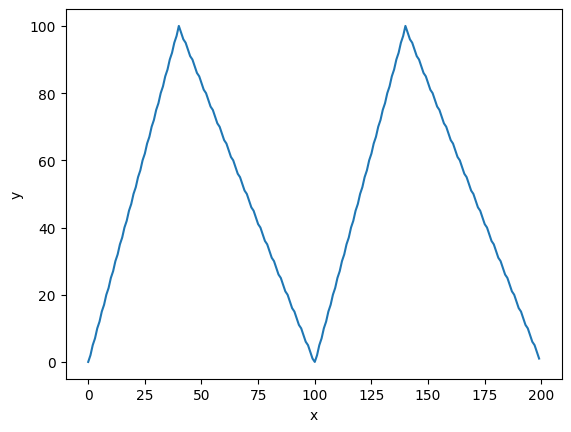

In [56]:
# Herman. Prøver å forstå alt sammen. Tegner potensialet.
# Må modifisere litt. Kan ikke sammenligne et helt array med periode, siden hver verdi for forskjellig bool-verdi.

alfa = 0.4
def V1_test(x):
    potensialer = np.zeros_like(x)
    for i in range(np.size(x)):
        periode = x[i] % Nx
        # print(periode)    # Går fra 0 til 99 to ganger.
        if periode <= alfa*Nx:
            potensialer[i] = 100*periode/(alfa*Nx)
        else:
            potensialer[i] = -100*(periode-Nx)/((1-alfa)*Nx)   
            # Nice Erik. Du er alltid to skritt foran meg. For eksempel her med -Nx.
        # print(potensialer[i])
    return potensialer
    
x_axis = np.arange(0,L, 1)
plt.plot(x_axis, V1_test(x_axis))
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Oppgave 3b)